Name: Lin Qizhou

Key insights / takeaways:
- I trained a Flow Matching (Rectified Flow) generative model on floorplan images by learning a time-dependent velocity field that transports noise to data.
- I implemented a simple U-Net style backbone with time conditioning and optimized an MSE objective between predicted and target velocities.
- I generated new synthetic floorplans by integrating the learned ODE with an Euler sampler, and saved grids of samples for qualitative evaluation.


In [3]:
!pip -q install -U torch torchvision pillow tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 93.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [4]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))


Saving floorplans_v2-20251223T170650Z-3-001.zip to floorplans_v2-20251223T170650Z-3-001.zip
['floorplans_v2-20251223T170650Z-3-001.zip']


In [5]:
from pathlib import Path
import zipfile

root = Path("/content")
zip_candidates = sorted(root.rglob("floorplans*.zip"))
if not zip_candidates:
    raise FileNotFoundError("floorplans*.zip not found under /content")

zip_path = zip_candidates[0]

workdir = Path("/content/work_floorplans")
workdir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(workdir)

img_exts = {".png", ".jpg", ".jpeg", ".webp"}
img_files = [p for p in workdir.rglob("*") if p.suffix.lower() in img_exts]

if not img_files:
    raise RuntimeError("no images found after extraction")

print(str(zip_path))
print(str(workdir))
print(len(img_files))
print(str(img_files[0]))


/content/floorplans_v2-20251223T170650Z-3-001.zip
/content/work_floorplans
1000
/content/work_floorplans/floorplans_v2/floorplan_00859.jpg


In [6]:
!pip -q install -U --force-reinstall "Pillow>=10.4.0"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [7]:
import PIL
print(PIL.__version__)


11.3.0


In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

workdir = Path("/content/work_floorplans")
img_exts = {".png", ".jpg", ".jpeg", ".webp"}
img_paths = sorted([p for p in workdir.rglob("*") if p.suffix.lower() in img_exts])
if not img_paths:
    raise RuntimeError("no images found")

size = 128
batch_size = 32
num_workers = 0

transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

class FloorplanDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

ds = FloorplanDataset(img_paths, transform)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)

x = next(iter(dl))
print(len(ds))
print(tuple(x.shape))
print(float(x.min()), float(x.max()))


1000
(32, 3, 128, 128)
-1.0 1.0


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(str(device))

def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device).float() / half)
    args = t[:, None] * freqs[None, :]
    emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros((t.shape[0], 1), device=t.device)], dim=-1)
    return emb

class ResBlock(nn.Module):
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.temb = nn.Linear(t_dim, c_out)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()
        self.gn1 = nn.GroupNorm(8, c_out)
        self.gn2 = nn.GroupNorm(8, c_out)

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.temb(t_emb)[:, :, None, None]
        h = F.silu(self.gn1(h))
        h = self.conv2(h)
        h = F.silu(self.gn2(h))
        return h + self.skip(x)

class Down(nn.Module):
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.rb = ResBlock(c_in, c_out, t_dim)
        self.pool = nn.AvgPool2d(2)

    def forward(self, x, t_emb):
        s = self.rb(x, t_emb)
        d = self.pool(s)
        return s, d

class Up(nn.Module):
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.rb = ResBlock(c_in, c_out, t_dim)

    def forward(self, x, skip, t_emb):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = torch.cat([x, skip], dim=1)
        x = self.rb(x, t_emb)
        return x

class UNetLite(nn.Module):
    def __init__(self, in_ch=3, base=64, t_dim=256):
        super().__init__()
        self.t_dim = t_dim
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim, t_dim),
            nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )

        self.d1 = Down(in_ch, base, t_dim)
        self.d2 = Down(base, base * 2, t_dim)
        self.d3 = Down(base * 2, base * 4, t_dim)

        self.mid = ResBlock(base * 4, base * 4, t_dim)

        self.u3 = Up(base * 8, base * 2, t_dim)
        self.u2 = Up(base * 4, base, t_dim)
        self.u1 = Up(base * 2, base, t_dim)

        self.out = nn.Conv2d(base, in_ch, 1)

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.t_dim)
        t_emb = self.t_mlp(t_emb)

        s1, x = self.d1(x, t_emb)
        s2, x = self.d2(x, t_emb)
        s3, x = self.d3(x, t_emb)

        x = self.mid(x, t_emb)

        x = self.u3(x, s3, t_emb)
        x = self.u2(x, s2, t_emb)
        x = self.u1(x, s1, t_emb)

        return self.out(x)

model = UNetLite().to(device)
print(sum(p.numel() for p in model.parameters()))


cpu
3872579


In [10]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

lr = 2e-4
epochs = 3
grad_clip = 1.0

opt = torch.optim.AdamW(model.parameters(), lr=lr)

def fm_loss(x0):
    b = x0.shape[0]
    t = torch.rand(b, device=x0.device)
    x1 = torch.randn_like(x0)
    xt = (1.0 - t)[:, None, None, None] * x0 + t[:, None, None, None] * x1
    v_target = x1 - x0
    v_pred = model(xt, t)
    return F.mse_loss(v_pred, v_target)

model.train()
for ep in range(epochs):
    pbar = tqdm(dl, total=len(dl))
    avg = 0.0
    n = 0
    for x0 in pbar:
        x0 = x0.to(device)
        loss = fm_loss(x0)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        opt.step()
        avg += float(loss.item())
        n += 1
        pbar.set_description(f"ep={ep+1}/{epochs} loss={avg/n:.4f}")


ep=3/3 loss=0.2131: 100%|██████████| 31/31 [15:44<00:00, 30.47s/it]


In [11]:
import torch
from torchvision.utils import make_grid, save_image
from pathlib import Path

@torch.no_grad()
def sample_rectified_flow(model, n, steps, shape, device):
    model.eval()
    x = torch.randn((n, *shape), device=device)
    t = torch.ones(n, device=device)
    dt = 1.0 / steps
    for k in range(steps):
        v = model(x, t)
        x = x - dt * v
        t = t - dt
    return x

outdir = Path("/content/floorplan_samples")
outdir.mkdir(parents=True, exist_ok=True)

n_samples = 16
steps = 50
shape = (3, 128, 128)

samples = sample_rectified_flow(model, n_samples, steps, shape, device)
samples_vis = (samples.clamp(-1, 1) + 1) / 2.0

grid = make_grid(samples_vis, nrow=4)
out_path = outdir / f"samples_n{n_samples}_steps{steps}.png"
save_image(grid, out_path)

print(str(out_path))

/content/floorplan_samples/samples_n16_steps50.png


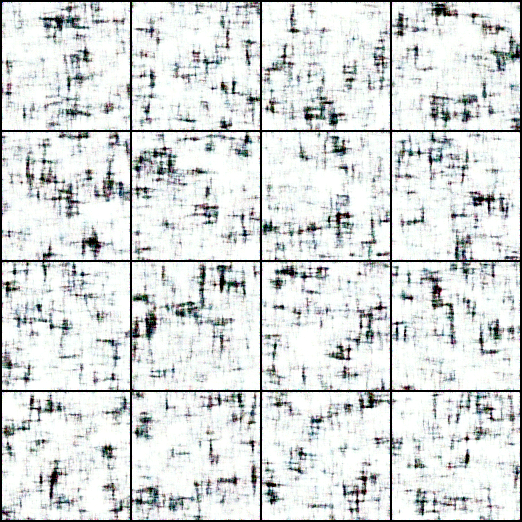

In [12]:
from PIL import Image
from IPython.display import display

img = Image.open(str(out_path))
display(img)

In [13]:
import torch
from pathlib import Path

ckpt_dir = Path("/content/floorplan_checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)

ckpt_path = ckpt_dir / "flow_matching_unetlite_floorplans.pth"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "image_size": 128,
        "in_channels": 3,
        "base_channels": 64,
        "t_dim": 256,
    },
    ckpt_path,
)

print(str(ckpt_path))

/content/floorplan_checkpoints/flow_matching_unetlite_floorplans.pth


In [14]:
import torch
from torchvision.utils import make_grid, save_image
from pathlib import Path

@torch.no_grad()
def generate_floorplans(model, outdir, n_samples=16, steps=50, size=128, seed=0, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    model.eval()
    x = torch.randn((n_samples, 3, size, size), device=device, generator=g)
    t = torch.ones(n_samples, device=device)
    dt = 1.0 / steps

    for _ in range(steps):
        v = model(x, t)
        x = x - dt * v
        t = t - dt

    x = (x.clamp(-1, 1) + 1) / 2.0
    grid = make_grid(x, nrow=int(n_samples ** 0.5))
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    out_path = outdir / f"samples_n{n_samples}_steps{steps}_seed{seed}.png"
    save_image(grid, out_path)
    return str(out_path)

In [15]:
outdir = "/content/floorplan_samples_step7"
paths = []
for seed in [0, 1, 2]:
    for steps in [25, 50, 100]:
        p = generate_floorplans(model, outdir=outdir, n_samples=16, steps=steps, size=128, seed=seed, device=device)
        paths.append(p)

print("\n".join(paths))

/content/floorplan_samples_step7/samples_n16_steps25_seed0.png
/content/floorplan_samples_step7/samples_n16_steps50_seed0.png
/content/floorplan_samples_step7/samples_n16_steps100_seed0.png
/content/floorplan_samples_step7/samples_n16_steps25_seed1.png
/content/floorplan_samples_step7/samples_n16_steps50_seed1.png
/content/floorplan_samples_step7/samples_n16_steps100_seed1.png
/content/floorplan_samples_step7/samples_n16_steps25_seed2.png
/content/floorplan_samples_step7/samples_n16_steps50_seed2.png
/content/floorplan_samples_step7/samples_n16_steps100_seed2.png


In [16]:
import torch
from pathlib import Path

ckpt_path = Path("/content/floorplan_checkpoints/flow_matching_unetlite_floorplans.pth")
if not ckpt_path.exists():
    raise FileNotFoundError(str(ckpt_path))

state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state["model_state_dict"])
model.to(device)
print("ok")

ok
